In [1]:
import sys
import os

# Get the directory of the current notebook
current_dir = os.path.dirname(os.path.abspath('__file__'))

# Move up to the root directory
root_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Add the root directory to the sys.path
sys.path.append(root_dir)

from graph_gen.gen_graph import gen_graph
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain import hub
import json
from langchain_openai.chat_models import ChatOpenAI
from langchain.agents import create_openai_functions_agent
from langgraph.prebuilt.tool_executor import ToolExecutor
from typing import Annotated, Dict, List, Optional, TypedDict, Tuple, Sequence, Union, Literal
from langchain_core.messages import AIMessage, BaseMessage, FunctionMessage, HumanMessage, ToolMessage
from langgraph.graph import END, StateGraph, MessageGraph
from langchain_core.agents import AgentAction, AgentFinish
from langgraph.prebuilt import ToolInvocation
from langchain_core.utils.function_calling import convert_to_openai_function
from langchain.output_parsers.openai_tools import (
    JsonOutputToolsParser,
    PydanticToolsParser
)
from langchain.agents.output_parsers.openai_functions import OpenAIFunctionsAgentOutputParser
import operator
import re

### [LangGraph: Chat Agent Executor](https://www.youtube.com/watch?v=Un-88uJKdiU&list=PLfaIDFEXuae16n2TWUkKq5PgJ0w6Pkwtg&index=3) <img src="https://upload.wikimedia.org/wikipedia/commons/4/42/YouTube_icon_%282013-2017%29.png" alt="YouTube" width="20" height="20">

In [2]:
# Graph   
graph_spec = """

call_model(AgentState)
    has_function_call => call_tool

call_tool
    => call_model

"""

# Conditional edges
def has_function_call(state):
    last_message = state["messages"][-1]
    return "function_call" in last_message.additional_kwargs

In [3]:
# State
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    intermediate_steps: Annotated[Sequence[BaseMessage], operator.add]

In [4]:
# Tools
tools = [TavilySearchResults(max_results=1)]
functions = [convert_to_openai_function(tool) for tool in tools]
model = ChatOpenAI(model="gpt-4o", temperature=0, streaming=True)
model = model.bind_functions(functions)
tool_executor = ToolExecutor(tools)

def print_result(s):
    if 'agent' in s and 'agent_outcome' in s['agent'] and isinstance(s['agent']['agent_outcome'], AgentFinish):
        print(s['agent']['agent_outcome'].return_values['output'])
    else:
        print(s)
    print()

/var/folders/cd/3w8prkld6nv0s9kb69pf_wy80000gn/T/ipykernel_5686/4141331373.py:6: LangGraphDeprecationWarning: ToolExecutor is deprecated as of version 0.2.0 and will be removed in 0.3.0. Use langgraph.prebuilt.ToolNode instead.
  tool_executor = ToolExecutor(tools)


In [5]:
# Nodes
def call_model(state):
    messages = state["messages"]
    response = model.invoke(messages)
    return { "messages": [response] }

def call_tool(state):
    messages = state["messages"]
    last_message = messages[-1]
    action = ToolInvocation(
        tool=last_message.additional_kwargs["function_call"]["name"],
        tool_input=json.loads(last_message.additional_kwargs["function_call"]["arguments"])
    )
    response = tool_executor.invoke(action)
    function_message = FunctionMessage(content=str(response), name=action.tool)
    return { "intermediate_steps": [function_message] }

In [6]:
# Run the graph
# - generate the python langgraph code
# - execute the code, runnable graph in variable 'app'
# - test the graph
graph_code = gen_graph("chat_agent_executor", graph_spec)
exec(graph_code)

# 'graph' contains the compiled graph
inputs = { "messages": [HumanMessage(content="who is a famous voice actress from the 50s")], "intermediate_steps": [] }
for s in chat_agent_executor.stream(inputs):
    print_result(s)

{'call_model': {'messages': [AIMessage(content='A famous voice actress from the 1950s is June Foray. She is best known for her work in animated television and film, providing voices for characters such as Rocky the Flying Squirrel in "The Rocky and Bullwinkle Show," Granny in the "Looney Tunes" series, and many others. June Foray\'s extensive career and versatile voice acting made her a significant figure in the animation industry during that era.', response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_3aa7262c27'}, id='run-d3368970-3bdd-4791-97f6-091fb0869656-0')]}}



In [7]:
print(graph_code)

chat_agent_executor = StateGraph(AgentState)
chat_agent_executor.add_node('call_model', call_model)
chat_agent_executor.add_node('call_tool', call_tool)

chat_agent_executor.set_entry_point('call_model')

def after_call_model(state: AgentState):
    if has_function_call(state):
        return 'call_tool'
    return END

call_model_dict = {'call_tool': 'call_tool', END: END}
chat_agent_executor.add_conditional_edges('call_model', after_call_model, call_model_dict)

chat_agent_executor.add_edge('call_tool', 'call_model')

chat_agent_executor = chat_agent_executor.compile()


In [8]:
messages = [HumanMessage(content="who invented tonal?")]
for s in chat_agent_executor.stream({"messages": messages, "intermediate_steps": []}):
    print(s)
    if 'call_model' in s and 'messages' in s['call_model']:
        message = s['call_model']['messages'][-1]
        print(f"\n{message.content}") if message.content else print(message.additional_kwargs)

{'call_model': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'arguments': '{\n  "query": "who invented Tonal fitness system"\n}', 'name': 'tavily_search_results_json'}}, response_metadata={'finish_reason': 'function_call', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_3aa7262c27'}, id='run-39885d82-fb18-4e0d-b038-c1cf2a61b572-0')]}}
{'function_call': {'arguments': '{\n  "query": "who invented Tonal fitness system"\n}', 'name': 'tavily_search_results_json'}}


/var/folders/cd/3w8prkld6nv0s9kb69pf_wy80000gn/T/ipykernel_5686/2431421414.py:10: LangGraphDeprecationWarning: ToolInvocation is deprecated as of version 0.2.0 and will be removed in 0.3.0. Use langgraph.prebuilt.ToolNode instead.
  action = ToolInvocation(


{'call_tool': {'intermediate_steps': [FunctionMessage(content='[{\'url\': \'https://www.tonal.com/blog/introducing-tonal-the-worlds-most-intelligent-fitness-system/\', \'content\': "Introducing Tonal: The World\'s Most Intelligent Fitness System. Aly Orady, Tonal\'s founder, on creating the smartest home gym. Tonal is the fitness experience I always wanted. An entire gym and personal trainer in my home. Tonal is so advanced that even professional athletes have fallen in love with it. It\'s so simple, that people who ..."}]', name='tavily_search_results_json')]}}
{'call_model': {'messages': [AIMessage(content='The Tonal fitness system was invented by Aly Orady. He founded the company in 2015 with the goal of creating a more efficient and effective way for people to work out at home using digital weights and personalized training programs.', response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_3aa7262c27'}, id='run-ae19c162-1a58-4578-a2

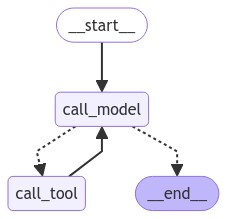

In [9]:
from IPython.display import Image, display

try:
    display(Image(chat_agent_executor.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### 

In [11]:
from langgraph.prebuilt import ToolNode

In [12]:
ToolNode??

Init signature:
ToolNode(
    tools: Sequence[Union[langchain_core.tools.base.BaseTool, Callable]],
    *,
    name: str = 'tools',
    tags: Optional[list[str]] = None,
    handle_tool_errors: Optional[bool] = True,
) -> None
Source:        
class ToolNode(RunnableCallable):
    """A node that runs the tools called in the last AIMessage.

    It can be used either in StateGraph with a "messages" key or in MessageGraph. If
    multiple tool calls are requested, they will be run in parallel. The output will be
    a list of ToolMessages, one for each tool call.

    The `ToolNode` is roughly analogous to:

    ```python
    tools_by_name = {tool.name: tool for tool in tools}
    def tool_node(state: dict):
        result = []
        for tool_call in state["messages"][-1].tool_calls:
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
       